## Dataset Overview
9,360 transaction-level rows, each representing one product-line sale by one retailer, in one region, over Jan 2020–Dec 2021. Total Sales is assumed to be net revenue (post-discount), based on the discrepancy pattern found in Section 2 — this is an inference from the data, not confirmed by dataset documentation, since no discount/tax/shipping column exists. Currency is unspecified in the source; assumed USD given US-only regions. Source: Kaggle (krishnavamsis/nike-sales), not official Nike data — used here as a business case only.

## 1. Load & Sanity Check
Redoing the checks I already did manually in Excel: row count, dtypes, missing values, duplicates, but in code this time so it's repeatable. Invoice Date needs an explicit day-first format (DD-MM-YYYY), otherwise Pandas guesses wrong on some dates.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda x: f'{x:,.1f}')

df = pd.read_csv('Nike Dataset.csv')
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'], format='%d-%m-%Y')
df['Year'] = df['Invoice Date'].dt.year
df['Month'] = df['Invoice Date'].dt.to_period('M')

assert df.duplicated().sum() == 0
assert df.isnull().sum().sum() == 0
print(f"{df.shape[0]} rows, {df.shape[1]} columns")

9360 rows, 11 columns


## 2. Rebuild the Discrepancy Check + Discrepancy Diagnostic
Calculated Sales and Discrepancy were already built manually in Excel (found 79.65% mismatch there). Rebuilding them here in code, plus a Discrepancy Rate (the mismatch as a % of Calculated Sales) since flagging by raw Total Sales would incorrectly treat legitimately high-value transactions as anomalies. The flag below identifies discrepancy rates that fall outside the typical range among mismatched rows. This marks values as statistically unusual relative to the distribution, not as confirmed errors.

In [21]:
df['Calculated Sales'] = df['Price per Unit'] * df['Units Sold']
df['Discrepancy'] = df['Total Sales'] - df['Calculated Sales']
df['Discrepancy Rate'] = df['Discrepancy'] / df['Calculated Sales'].replace(0, np.nan) * 100
df['Match Status'] = np.where(df['Discrepancy'].abs() < 0.01, 'Match', 'Mismatch')

# flag extreme discrepancies using IQR on the RATE, not on raw Total Sales —
# a high-value transaction isn't inherently suspicious, an unusual discount
# percentage is what actually needs investigating
mismatches = df.loc[df['Match Status'] == 'Mismatch', 'Discrepancy Rate']
q1, q3 = mismatches.quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr

df['Discrepancy Flag'] = np.where(
    df['Match Status'] == 'Match', 'Match',
    np.where(df['Discrepancy Rate'].between(lo, hi), 'Expected Range', 'Extreme Discrepancy')
)
print(df['Discrepancy Flag'].value_counts())

Discrepancy Flag
Expected Range         5605
Match                  1905
Extreme Discrepancy    1850
Name: count, dtype: int64


## 3. KPI Table by Product
Revenue, units, average price, and each product's share of total revenue, all in one groupby instead of separate calculations.

In [3]:
kpi = (df.groupby('Product')
         .agg(revenue=('Total Sales', 'sum'),
              units=('Units Sold', 'sum'),
              avg_price=('Price per Unit', 'mean'))
         .assign(pct_of_revenue=lambda d: d['revenue'] / d['revenue'].sum() * 100)
         .sort_values('revenue', ascending=False))
kpi

,revenue,units,avg_price,pct_of_revenue
Product,,,,
Men's Street Footwear,1999192,57737,43.8,23.2
Women's Apparel,1720630,42356,51.1,19.9
Men's Athletic Footwear,1468116,42429,43.3,17.0
Women's Street Footwear,1224756,38309,39.7,14.2
Men's Apparel,1192682,30085,49.9,13.8
Women's Athletic Footwear,1023899,31068,40.7,11.9


## 4. Where Is the Mismatch Coming From
Checking whether the 79.65% mismatch is spread evenly or concentrated in one dimension (Sales Method, Retailer, Region, Product). This decides whether it's a data bug or a real business pattern, like unrecorded discounts.

In [4]:
def mismatch_breakdown(frame, dims):
    return {d: (frame.groupby(d)['Match Status']
                     .apply(lambda x: (x == 'Mismatch').mean() * 100)
                     .sort_values(ascending=False))
            for d in dims}

for dim, result in mismatch_breakdown(df, ['Sales Method', 'Retailer', 'Region', 'Product']).items():
    print(f"\n{dim}")
    print(result.round(1))


Sales Method
Sales Method
Online     90.5
Outlet     81.9
In-store   46.2
Name: Match Status, dtype: float64

Retailer
Retailer
Sports Direct   82.5
Amazon          80.7
Foot Locker     79.4
Walmart         78.9
West Gear       78.7
Kohl's          76.7
Name: Match Status, dtype: float64

Region
Region
South       83.5
Southeast   81.3
Northeast   80.3
West        79.4
Midwest     74.4
Name: Match Status, dtype: float64

Product
Product
Women's Street Footwear     80.8
Women's Athletic Footwear   80.6
Men's Apparel               79.6
Women's Apparel             79.5
Men's Street Footwear       79.1
Men's Athletic Footwear     78.3
Name: Match Status, dtype: float64


In [22]:
print("\nMismatch % by Month")
print(df.groupby('Month')['Match Status'].apply(lambda x: (x=='Mismatch').mean()*100).round(1))


Mismatch % by Month
Month
2020-01   73.3
2020-02   74.6
2020-03   83.2
2020-04   84.6
2020-05   72.6
2020-06   70.0
2020-07   76.0
2020-08   73.4
2020-09   76.0
2020-10   70.9
2020-11   83.8
2020-12   82.6
2021-01   82.5
2021-02   78.5
2021-03   80.4
2021-04   81.8
2021-05   80.2
2021-06   78.1
2021-07   76.6
2021-08   80.7
2021-09   81.2
2021-10   80.1
2021-11   80.3
2021-12   79.7
Freq: M, Name: Match Status, dtype: float64


## 5. Price vs Units, and Monthly Growth
Checking whether higher price actually means fewer units sold, then looking at month-over-month growth instead of just raw monthly totals, since the raw numbers hide how volatile early months are.

In [5]:
corr = df[['Price per Unit', 'Units Sold']].corr().iloc[0, 1]
print(f"Price vs Units correlation: {corr:.2f}")

monthly = df.groupby('Month')['Total Sales'].sum()
mom_growth = monthly.pct_change() * 100
mom_growth.round(1)

Price vs Units correlation: 0.27


,Total Sales
Month,
2020-01,NaN
2020-02,-7.7
2020-03,17.8
2020-04,39.3
2020-05,-31.2
2020-06,-47.8
2020-07,94.2
2020-08,15.9
2020-09,-7.9


## 6. Checking the 2020 → 2021 Jump
Before calling this "revenue growth," checking whether it's organic or just a difference in how many transactions/retailers were actually recorded each year.

In [6]:
print(df.groupby('Year').size().rename('transactions'))
print(df.groupby('Year')['Retailer'].nunique().rename('active_retailers'))
pd.crosstab(df['Retailer'], df['Year'])

Year
2020    1302
2021    8058
Name: transactions, dtype: int64
Year
2020    5
2021    6
Name: active_retailers, dtype: int64


Year,2020,2021
Retailer,,
Amazon,0,823
Foot Locker,337,2208
Kohl's,8,1022
Sports Direct,106,1900
Walmart,216,366
West Gear,635,1739


## 7 Multi-Dimensional View: Product x Region
Revenue by product alone or region alone hides interaction effects. This pivot shows both at once, so I can see if West's lead holds across every product or is driven by just one or two categories.

In [16]:
 revenue_by_product_region = pd.pivot_table(
    df, values='Total Sales', index='Product', columns='Region', aggfunc='sum'
)
revenue_by_product_region

Region,Midwest,Northeast,South,Southeast,West
Product,,,,,
Men's Apparel,181280,257478,197045,244623,312256
Men's Athletic Footwear,213076,288773,257118,277784,431365
Men's Street Footwear,383248,510281,284459,360206,460998
Women's Apparel,282086,375453,296081,314924,452086
Women's Athletic Footwear,135979,197996,184225,203041,302658
Women's Street Footwear,162476,233448,227794,231208,369830


## 8. Visualizations
Six charts: revenue by product, monthly revenue trend, mismatch rate by sales method, spread of Total Sales across regions, a heatmap of revenue by product and region combined, and a Pareto chart showing how revenue concentrates across products.

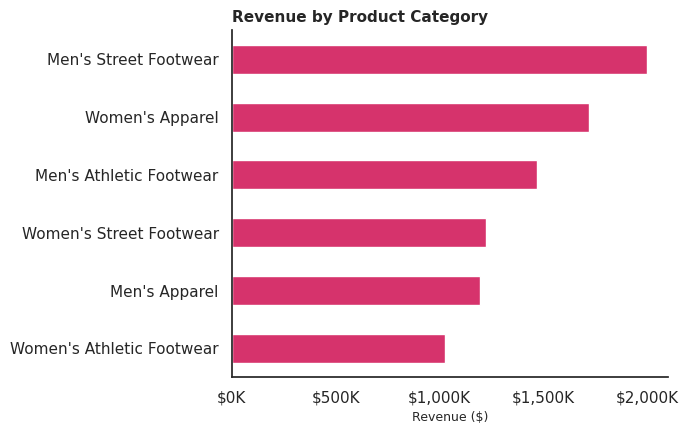

In [12]:
sns.set_theme(style="white")
pink = ['#D6336C', '#F783AC', '#FFC9DE', '#A61E4D']

fig, ax = plt.subplots(figsize=(7, 4.5))
kpi['revenue'].sort_values().plot(kind='barh', ax=ax, color=pink[0])
ax.set_title('Revenue by Product Category', fontsize=11, fontweight='bold', loc='left')
ax.set_xlabel('Revenue ($)', fontsize=9)
ax.set_ylabel('')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'${x/1000:,.0f}K'))
plt.tight_layout()
plt.show()

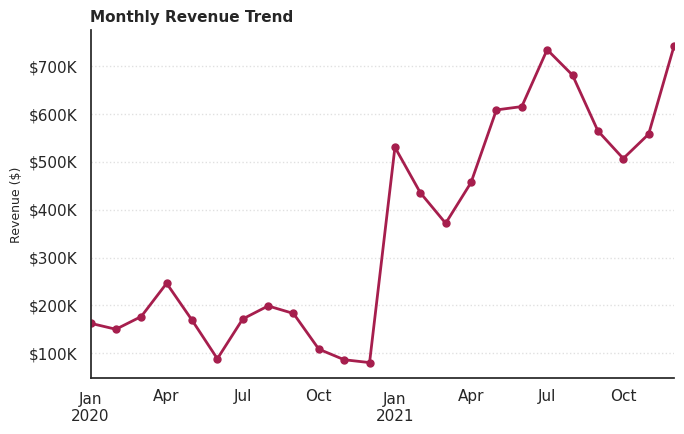

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))
monthly.plot(ax=ax, color=pink[3], marker='o', linewidth=2, markersize=5)
ax.set_title('Monthly Revenue Trend', fontsize=11, fontweight='bold', loc='left')
ax.set_xlabel('')
ax.set_ylabel('Revenue ($)', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'${x/1000:,.0f}K'))
ax.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

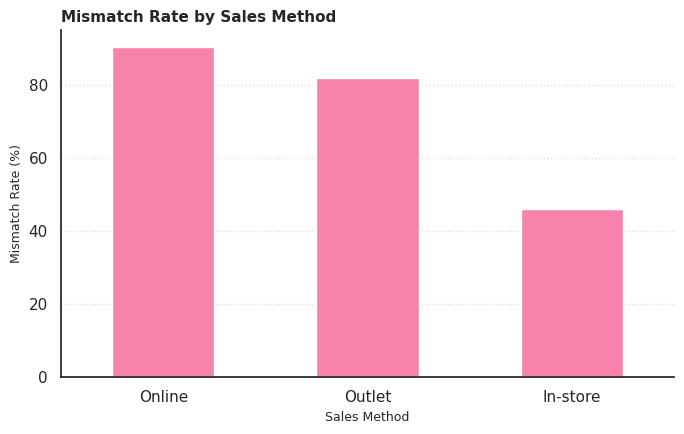

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
mismatch_breakdown(df, ['Sales Method'])['Sales Method'].plot(kind='bar', ax=ax, color=pink[1], rot=0)
ax.set_title('Mismatch Rate by Sales Method', fontsize=11, fontweight='bold', loc='left')
ax.set_xlabel('Sales Method', fontsize=9)
ax.set_ylabel('Mismatch Rate (%)', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

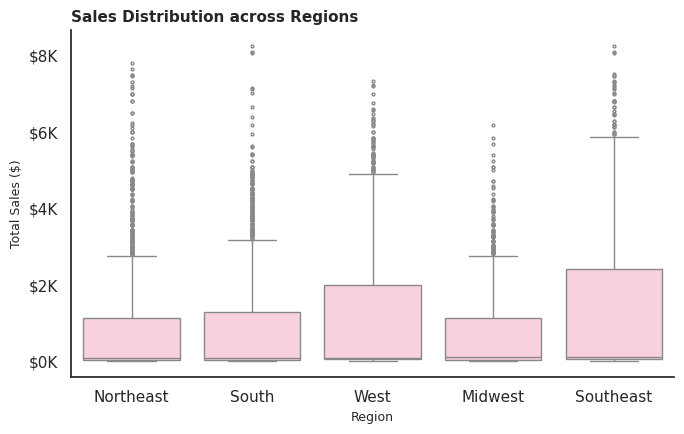

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=df, x='Region', y='Total Sales', ax=ax, color=pink[2], fliersize=2)
ax.set_title('Sales Distribution across Regions', fontsize=11, fontweight='bold', loc='left')
ax.set_xlabel('Region', fontsize=9)
ax.set_ylabel('Total Sales ($)', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'${x/1000:,.0f}K'))
plt.tight_layout()
plt.show()

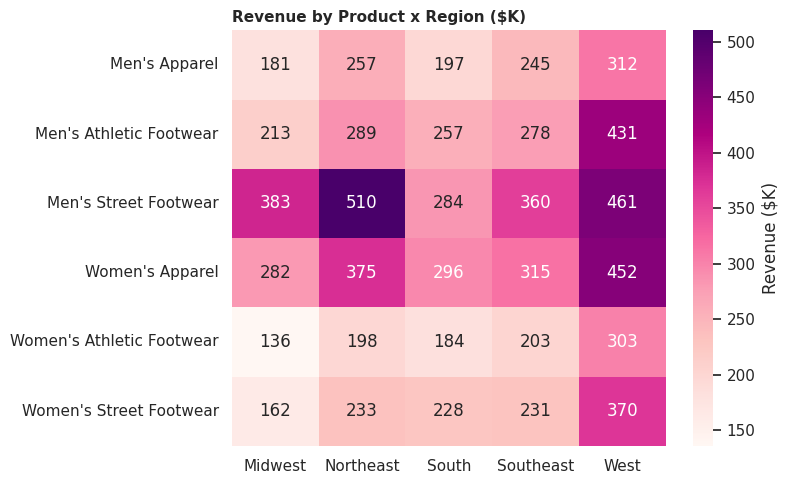

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(revenue_by_product_region / 1000, annot=True, fmt='.0f', cmap='RdPu', ax=ax, cbar_kws={'label': 'Revenue ($K)'})
ax.set_title('Revenue by Product x Region ($K)', fontsize=11, fontweight='bold', loc='left')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

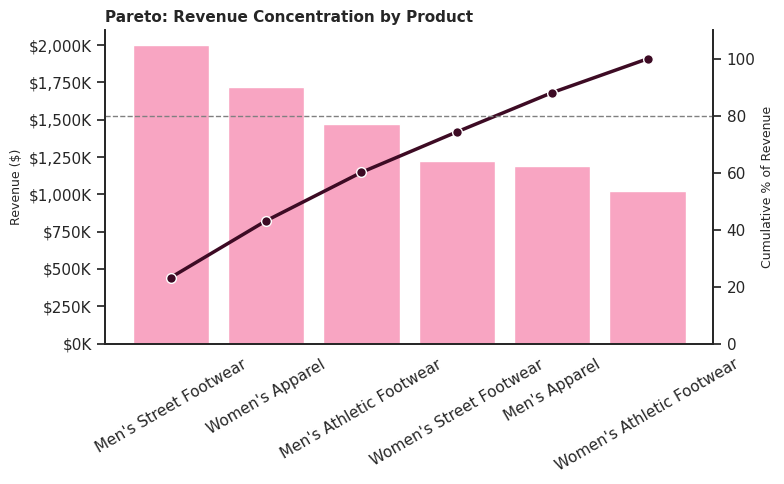

In [19]:
kpi_sorted = df.groupby('Product')['Total Sales'].sum().sort_values(ascending=False)
cum_pct = kpi_sorted.cumsum() / kpi_sorted.sum() * 100

bar_color = '#F8A5C2'
line_color = '#3D0B24'

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(kpi_sorted.index, kpi_sorted.values, color=bar_color)
ax1.set_ylabel('Revenue ($)', fontsize=9)
ax1.spines[['top']].set_visible(False)
ax1.tick_params(axis='x', rotation=30)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'${x/1000:,.0f}K'))

ax2 = ax1.twinx()
ax2.plot(kpi_sorted.index, cum_pct.values, color=line_color, marker='o',
         linewidth=2.5, markersize=7, markeredgecolor='white', markeredgewidth=1)
ax2.set_ylabel('Cumulative % of Revenue', fontsize=9)
ax2.set_ylim(0, 110)
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)
ax2.spines[['top']].set_visible(False)

ax1.set_title('Pareto: Revenue Concentration by Product', fontsize=11, fontweight='bold', loc='left')
plt.tight_layout()
plt.show()

## 9. Export
Saving the cleaned version for Power BI so I don't have to redo the cleaning there.

In [20]:
df.to_csv('nike_sales_cleaned.csv', index=False)
print(df.shape)

(9360, 15)


## 10. Key Findings

**1. Revenue is not concentrated in one hero product**
- Evidence: it takes the top 4 of 6 product categories to reach 80% of total revenue (see Pareto chart). Men's Street Footwear alone is only 23.2% of revenue.
- Business meaning: the product portfolio is broad, it's not riding on a single bestseller.
- Potential action: don't over-index inventory or marketing spend on Men's Street Footwear alone. The next three categories combined matter almost as much.

**2. West is the strongest region, and it's consistent across products**
- Evidence: West leads overall revenue (26.99%) and leads in nearly every row of the Product x Region heatmap, not just one category.
- Business meaning: West's strength isn't coming from one lucky product line, it's broad based.
- Potential action: worth looking into what's different about West's retailer mix, and whether any of that is repeatable in weaker regions like Midwest (15.74%).

**3. Total Sales likely reflects an unrecorded discount, mostly in Online and Outlet**
- Evidence: 79.65% of rows show Total Sales that doesn't equal Price times Units. The mismatch rate is 90.5% for Online and 81.9% for Outlet, compared to 46.2% for In-store. Within the mismatches, 1,850 rows show an "Extreme Discrepancy," and most of those cluster around a consistent ~90% reduction.
- Business meaning: this is probably a discount or promotion field that just isn't captured anywhere else in the dataset, so it's not necessarily a data quality error. That said, the repeating ~90% figure is specific enough that it's worth flagging for the data owner rather than assuming it's normal.
- Potential action: document this as a known limitation, and recommend that future data collection include an explicit discount amount or net vs gross sales field.

**4. The 2020 to 2021 revenue jump is probably a data coverage gap, not real growth**
- Evidence: 2020 only has 1,302 recorded transactions, while 2021 has 8,058. Amazon has zero recorded transactions at all in 2020.
- Business meaning: this looks like an observation about the dataset, not a confirmed growth story. There's no way to tell from this data alone whether the business actually grew or whether 2020 just wasn't tracked as completely.
- Potential action: avoid presenting this as "revenue grew 6x in 2021" without that caveat attached.

**5. Price and volume are only weakly related**
- Evidence: the correlation between Price per Unit and Units Sold is 0.27.
- Business meaning: higher priced items in this dataset aren't meaningfully selling in lower volumes.
- Potential action: revenue decisions per product can lean more on margin or positioning, since higher price doesn't appear to be killing volume here.

**Note:** findings 3 and 4 are interpretations, not confirmed facts. The underlying data source isn't accessible to verify the actual cause behind either pattern.